# Load packages

In [1]:
import scimap as sm
import anndata as ad
import pandas as pd
import numpy as np

Running SCIMAP  2.2.11


In [2]:
import scanpy as sc
import harmonypy as hm

# Load data

In [3]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_65670/1161626377.py:1: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



In [21]:
image_path = '/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv'
# Convert the data to scimap format
adata = sm.pp.mcmicro_to_scimap(image_path, 
                                remove_dna=False, remove_string_from_name=None, log=False, drop_markers=None,
                                random_sample=None, unique_CellId=True, CellId='CellID', split='X_centroid',
                                custom_imageid=None, min_cells=None, output_dir=None)
adata.obsm['spatial'] = np.array(adata.obs[['Y_centroid', 'X_centroid']])
adata

Loading Data_AllMarkers_filtered_RCNs.csv


/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/preprocessing/mcmicro_to_scimap.py:106: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM', 'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs', 'CellID', 'imageid'
    uns: 'all_markers'
    obsm: 'spatial'

In [22]:
# Preprocess data for downstream analysis

# Select markers for dimensionality reduction
markers = ['E.Cadherin', 'panCK', 'Vimentin', 'SMA', 'CD68', 'CD206', 'CD8a', 'CD4', 'FOXP3', 'CD45']
adata.var['highly_variable'] = [True if x in markers else False for x in adata.var_names]

# Subset to only the selected markers for dimensionality reduction
adata_markers = adata[:, adata.var['highly_variable']]

print(f"Data prepared for dimensionality reduction: {adata.shape}")

Data prepared for dimensionality reduction: (3681772, 25)


# UMAP

## Harmony

In [32]:
sc.tl.pca(adata_markers)

In [33]:
ho = hm.run_harmony(adata_markers.obsm['X_pca'], adata_markers.obs, 'imageid')

2025-03-31 12:09:11,829 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-03-31 12:11:39,700 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-03-31 12:11:57,351 - harmonypy - INFO - Iteration 1 of 10
2025-03-31 12:24:45,247 - harmonypy - INFO - Iteration 2 of 10
2025-03-31 12:37:19,383 - harmonypy - INFO - Iteration 3 of 10
2025-03-31 12:50:18,483 - harmonypy - INFO - Iteration 4 of 10
2025-03-31 13:03:01,272 - harmonypy - INFO - Iteration 5 of 10
2025-03-31 13:15:47,938 - harmonypy - INFO - Iteration 6 of 10
2025-03-31 13:28:27,574 - harmonypy - INFO - Iteration 7 of 10
2025-03-31 13:41:22,275 - harmonypy - INFO - Iteration 8 of 10
2025-03-31 13:54:13,031 - harmonypy - INFO - Converged after 8 iterations


In [34]:
adata_markers.obsm['X_pca'] = ho.Z_corr.T

In [35]:
sc.pp.neighbors(adata_markers, use_rep="X_pca")
sc.tl.umap(adata_markers)

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning:

Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!



In [36]:
adata_markers

AnnData object with n_obs × n_vars = 3681772 × 10
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM', 'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs', 'CellID', 'imageid'
    var: 'highly_variable'
    uns: 'all_markers', 'pca', 'neighbors', 'umap'
    obsm: 'spatial', 'umap', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

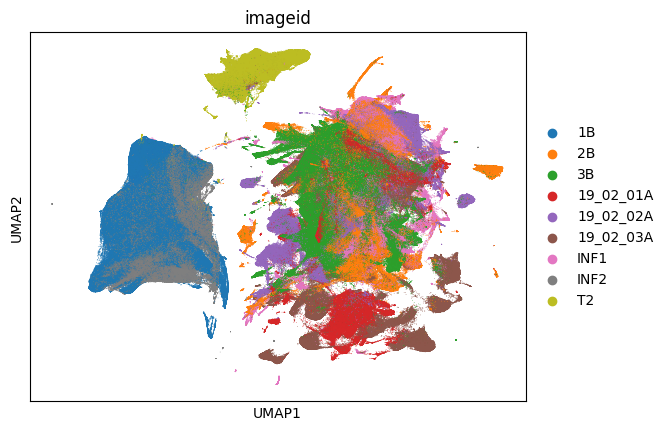

In [37]:
sc.pl.umap(adata_markers, color=['imageid'], s=1)

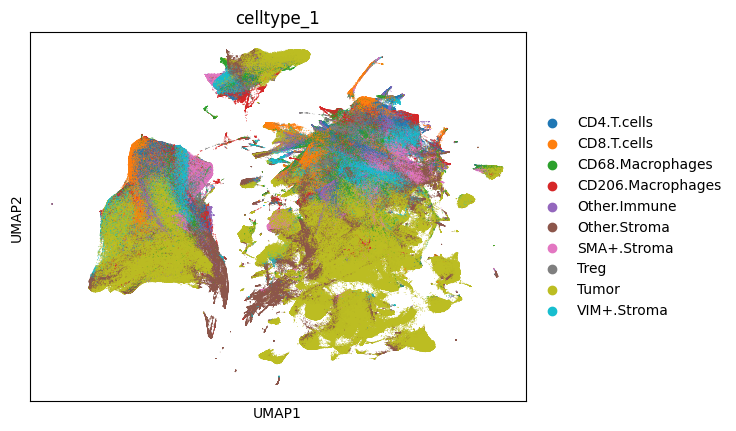

In [38]:
sc.pl.umap(adata_markers, color=['celltype_1'], s=1)

## Raw

In [ ]:
adata_markers

In [28]:
# view the phenotype on a UMAP
adata_markers = sm.tl.umap(adata_markers)

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/tools/umap.py:115: ImplicitModificationWarning:

Setting element `.obsm['umap']` of view, initializing view as actual.



/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/plotting/umap.py:304: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



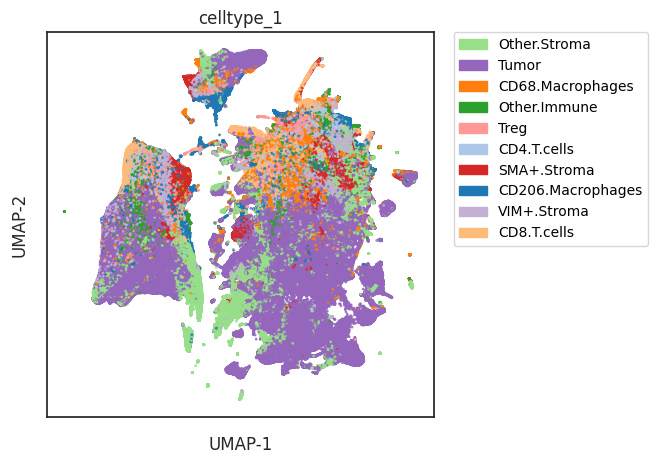

In [29]:
sm.pl.umap(adata_markers, color=['celltype_1'], s=1)

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/plotting/umap.py:304: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



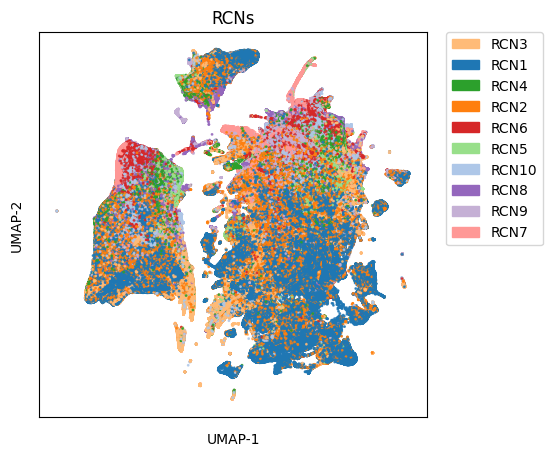

In [30]:
sm.pl.umap(adata_markers, color=['RCNs'], s=1)

In [ ]:
adata_markers.obsm['umap']

array([[ 3.460804 , -5.6698585],
       [ 6.0322437, -6.2773094],
       [ 3.386275 , -5.644295 ],
       ...,
       [ 3.4753659, 16.33705  ],
       [11.420055 , 14.987839 ],
       [ 1.0975821, 11.691911 ]], dtype=float32)

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/plotting/umap.py:304: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



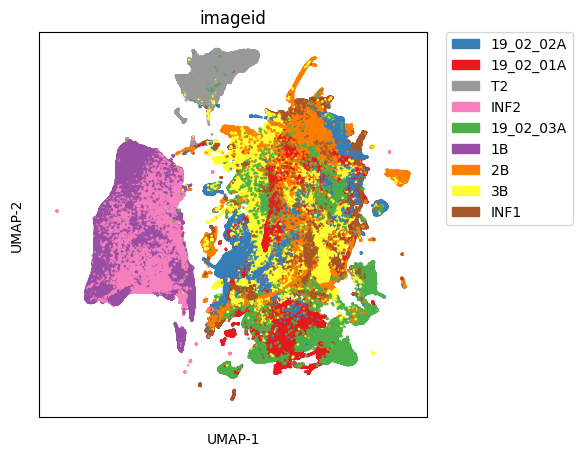

In [31]:
sm.pl.umap(adata_markers, color=['imageid'], s=1)

In [ ]:
adata_markers

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,...,NQO1_GCLC_VIM,celltype_2,celltype_1,Tumor_state,GCLC_VIM,CellCategory,SC45px_neigh_kmeans_10,RCNs,CellID,imageid
19_02_02A_1,2027.642,1011.2380,core77_19_02_02A,core77,Other,Invasive border,2,AB19-1654_P10158,282,0.821700,...,---,Other,Other.Stroma,Other.Stroma,Other.Stroma,Stroma,4,RCN3,1,19_02_02A
19_02_01A_10,5871.136,777.1124,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,258,0.620470,...,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,10,19_02_01A
19_02_02A_10,1999.424,1195.5040,core77_19_02_02A,core77,CD68.Macrophages,Invasive border,2,AB19-1654_P10158,125,0.755401,...,+--,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,Immune,4,RCN3,10,19_02_02A
19_02_01A_100,6136.928,858.5450,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,222,0.803584,...,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,100,19_02_01A
19_02_02A_100,1728.540,1302.0830,core77_19_02_02A,core77,Immune,Invasive border,2,AB19-1654_P10158,300,0.522613,...,---,Immune,Other.Immune,Other.Immune,Other.Immune,Immune,4,RCN3,100,19_02_02A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF1_99998,36889.410,6446.4120,core22_INF1,core22,Tumor,Inflammation,unknown,AB19-1654_P10648,148,0.641780,...,---,Tumor_---,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,99998,INF1
1B_99999,11181.530,7239.2680,core64_1B,core64,FOXP3.CD4.Tregs,Tumor center,2,AB19-1654_P10561,366,0.771436,...,-++,FOXP3.CD4.Tregs,Treg,Treg,Treg,Immune,1,RCN2,99999,1B
2B_99999,8371.249,6579.8230,core71_2B,core71,CD4.T.cells,Lymph node met,2,AB19-1654_P10599,558,0.863484,...,-++,CD4.T.cells,CD4.T.cells,CD4.T.cells,CD4.T.cells,Immune,1,RCN2,99999,2B
3B_99999,20828.410,4477.0180,core42_3B,core42,Tumor,Tumor center,1,AB19-1654_P10620,112,0.883622,...,---,Tumor_---,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1,99999,3B
